In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict

/Users/namitamehra/Documents/Applied AI/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
load_dotenv()

True

In [5]:
model = ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')

In [6]:
#creating a state
class LLMState(TypedDict):
    question : str
    answer : str


In [7]:
def Generate_answer(state: LLMState)-> LLMState:
    question = state['question']

    prompt = f'Answer the following question {question}'

    answer = model.invoke(prompt).content

    state['answer'] = answer

    return state

In [11]:
# defining graph
graph = StateGraph(LLMState)

# adding nodes
graph.add_node('Response', Generate_answer)

# adding edges
graph.add_edge(START, 'Response')
graph.add_edge('Response', END)

# compiling the graph
workflow = graph.compile()

#executing
final_state = workflow.invoke({'question':"What is The Best thing about Uttarakhand, Also there has been something like aanchri, devta kuldvi concept there, like jaagar etc, what is it?"})
print(final_state['answer'])


Uttarakhand is a state blessed with an abundance of natural beauty and cultural richness. Picking the "best" thing is subjective and depends on individual preferences, but here are some of the most widely celebrated aspects:

## The Best Thing About Uttarakhand: A Multi-Faceted Gem

It's difficult to pinpoint a single "best" thing, as Uttarakhand offers a diverse range of experiences. However, if forced to choose, a strong contender would be its **unparalleled natural beauty and spiritual serenity.**

Here's why:

*   **Majestic Himalayas:** Uttarakhand is home to some of the most breathtaking peaks in the Himalayas, including Nanda Devi, Trishul, and Kamet. These towering giants offer spectacular views, challenging trekking opportunities, and a sense of awe-inspiring grandeur.
*   **Pristine Natural Landscapes:** Beyond the mountains, you'll find lush green valleys, dense forests, crystal-clear rivers, and cascading waterfalls. Places like Jim Corbett National Park, Valley of Flowers,

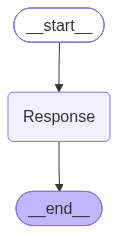

In [9]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())